# Semana 3 -  Teste de Hipótese e Previsão de Resposta

Uma névoa (gotículas transportadas pelo ar ou aerossóis) é gerada quando fluidos para remoção de metal são usados em operações de máquina para resfriar e lubrificar a ferramenta e a peça. A produção de névoa é uma preocupação para a *Occupational Safety and Health Administration* (OSHA), que recentemente diminuiu substancialmente o nível padrão nos locais de trabalho. 

O artigo *Variables affecting mist generation from metal removal fluids, (Lubrication Engr., 2002: 10-17)* apresentou os dados a seguir sobre x = velocidade do fluxo do fluido para um óleo 5 \% solúvel (cm/s) e y = a quantidade de gotículas de névoa com diâmetro menor que 10 mm (mg/m3):


## Tabela de dados

In [1]:
from tabulate import tabulate
table = [["x",  89 , 177,  189,  354,  362,  442,  965],
         ["y", 0.40, 0.60, 0.48, 0.66 ,  0.61,  0.69,  0.99 ]]
print(tabulate(table))

-  ----  -----  ------  ------  ------  ------  ------
x  89    177    189     354     362     442     965
y   0.4    0.6    0.48    0.66    0.61    0.69    0.99
-  ----  -----  ------  ------  ------  ------  ------


**1a.** Os pesquisadores executaram uma análise de regressão linear simples para relacionar as duas variáveis. O gráfico de dispersão dos dados apoia essa estratégia?

**1b.** Que proporção da variação observada no volume de névoa pode ser atribuída à relação de regressão linear simples entre velocidade e névoa?

**1c.** Os investigadores estavam particularmente interessados no impacto sobre a névoa ao aumentar a velocidade de 100 para 1000 (um fator de 10 correspondente à diferença entre o menor e o maior valores *x* na amostra). Quando x aumenta dessa forma, há alguma evidência significativa de que o aumento médio verdadeiro em *y* seja menor que 0,6?

**1d.** Estime a mudança média verdadeira na névoa associada com um aumento de velocidade de 1 cm/s. Faça isso de maneira que transmita informações sobre precisão e confiança.

## Resposta a.

Os pesquisadores executaram uma análise de regressão linear simples para relacionar as duas variáveis. O gráfico de dispersão dos dados apoia essa estratégia?
Verificar 📊

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
#Primeiro definir os dados
lstx = (89 , 177,  189,  354,  362,  442,  965)
lsty= (0.40, 0.60, 0.48, 0.66 ,  0.61,  0.69,  0.99 )
# Construir o DataFrame e nomear as colunas
df = pd.DataFrame(list(zip(lstx, lsty)),
               columns =["x","y"])
df

,x,y
0,89,0.40
1,177,0.60
2,189,0.48
3,354,0.66
4,362,0.61
5,442,0.69
6,965,0.99


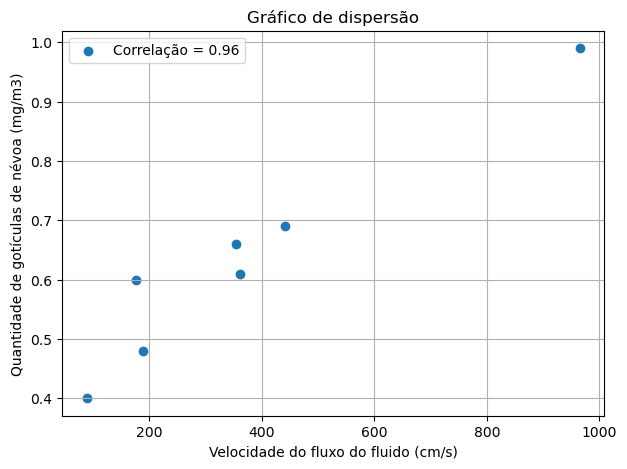

In [4]:
 #diagrama de dispersão
x=df['x']
y=df['y']
plt.rcParams.update({'figure.figsize':(7,5), 'figure.dpi':100})
plt.scatter(x,y, label=f'Correlação = {np.round(np.corrcoef(x,y)[0,1], 2)}')
plt.xlabel('Velocidade do fluxo do fluido (cm/s)')
plt.ylabel('Quantidade de gotículas de névoa (mg/m3)') 
plt.title('Gráfico de dispersão')
plt.legend()
plt.grid(True)
plt.show()

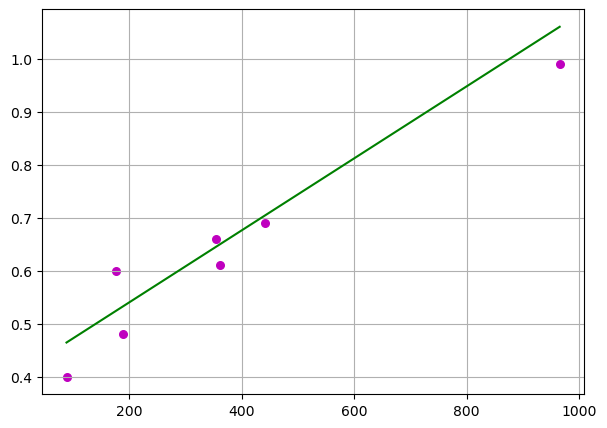

In [5]:
#yp Reta de regressão obtida com antecedência
yp=0.4041+0.00068*x 
plt.plot(x, yp, color = "g")
plt.scatter(x, y, color = "m",  marker = "o", s = 30)
plt.grid(True)

🙋 Sim, o diagrama de dispersão confirma que a estrágia adotada (regressão linear) é adequada para os dados

## Resposta b.


Que proporção da variação observada no volume de névoa pode ser atribuída à relação de regressão linear simples entre velocidade e névoa?

🤔💭 Posso medir a proporção mediante o coeficiente de correlação ou mediante o coeficiente de determinação?

🙋 Como está se referindo **à relação de regressão linear** simples entre velocidade (*x*) e névoa (*y*) então é **coeficiente de determinação**

In [6]:
x = sm.add_constant(x)
#fit linear regression model
modelo = sm.OLS(y, x).fit() #
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     67.15
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000440
Time:                        11:23:02   Log-Likelihood:                 11.671
No. Observations:                   7   AIC:                            -19.34
Df Residuals:                       5   BIC:                            -19.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4041      0.035     11.684      0.0

C:\Users\Amanda Rodrigues\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


**Explicação do resultado** OLS (*Ordinary Least Squares*)
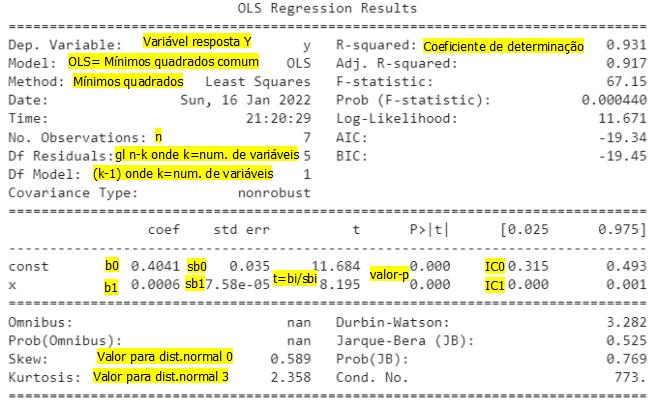

De acordo com as informações o $r^2=0,931$ o que indica que uma porcentagem de 93,1 \% de relação da quantidade de gotículas de névoa em função da velocidade do fluxo.

A reta de regressão é $Y= 0,4041 + 0,0006x$

Verificar calculando manualmente 

### função linreg

In [8]:

#O seguinte código pode também ser usado previamente para calcular SQE, SQT, SQR e r2 (Alternativa 2)
# fonte: Adaptado de https://www.geeksforgeeks.org/sum-function-python/
def linreg(X, Y):
    """
    retorna a solução b0 e b1 para a reta y = b0 + b1x e todas as somatórias necessárias
    """
    N = len(X)
    Sx = Sy = Sxx = Syy = Sxy = 0.0
    for x, y in zip(X, Y):
        Sx = Sx + x           # Somatória do termos x
        Sy = Sy + y           # Somatória do termos y
        Sxx = Sxx + x*x       # Somatória do termos x^2
        Syy = Syy + y*y       # Somatória do termos y^2
        Sxy = Sxy + x*y       # Somatória do termos x vezes y
    det = Sxx * N - Sx * Sx   # variável auxiliar
    Sxxt= Sxx - Sx*Sx/N       # Termo Sxx
    Sxyt= Sxy - Sx*Sy/N       # Termo Sxy  
    Syyt= Syy - Sy*Sy/N       # Termo Syy  
    r=Sxyt/pow((Sxxt*Syyt), 1/2)
    return (Sxy * N - Sy * Sx)/det, (Sxx * Sy - Sx * Sxy)/det, Sx, Sy, Sxx,  Syy , Sxy, Sxxt, Sxyt, Syyt,r

In [9]:
#obter os valores necessários para calcular SQE e afins
x=df['x']
y=df['y']
b1,b0,sox,soy,sox2,soy2,soxy,sxx,sxy,syy,corr = linreg(x,y)  
#Calcular SQE, SQT e SQR
sqe=syy-b1*sxy
sqt=syy
sqr=sqt-sqe
#calcular r^2 coeficiente de determinação
r2=1-sqe/sqt
#Calcular variância estimada
s2=sqe/(len(y)-2)
#Calcular desvio padrão estimado
s=pow(s2,1/2)
#Calcular erro padrão
ebeta=s/pow(sxx,1/2)

print('b0= {0},b1= {1}'.format(b0,b1))
print('Somatória x= {0}, Somatória y= {1},Somatória xy= {2}'.format(sox,soy,soxy))
print('Somatória x^2= {0}, Somatória y^2= {1}'.format(sox2,soy2))
print('Sxx= {0}, Syy {1}, Sxy {2}'.format(sxx,syy,sxy))
print('Coeficiente de correlação= {0}'.format(corr))
print('SQE= {0}, SQT {1}, SQR {2}'.format(sqe,sqt,sqr))
print('Variância estimada, s^2= {0}, Desvio padrão estimado, s= {1}'.format(s2,s))
print('Coeficente de determinação, r^2= {0}, Erro padrão, s_b1= {1}'.format(r2,ebeta))

b0= 0.40412378531397253,b1= 0.0006210758350667933
Somatória x= 2578.0, Somatória y= 4.43,Somatória xy= 1947.31
Somatória x^2= 1457920.0, Somatória y^2= 3.0142999999999995
Sxx= 508479.4285714285, Syy 0.21074285714285734, Sxy 315.8042857142857
Coeficiente de correlação= 0.9647280228801388
SQE= 0.014604446675185179, SQT 0.21074285714285734, SQR 0.19613841046767216
Variância estimada, s^2= 0.0029208893350370357, Desvio padrão estimado, s= 0.054045252659572565
Coeficente de determinação, r^2= 0.9307001581302222, Erro padrão, s_b1= 7.579156202786891e-05


In [ ]:
#print(modelo.t_test([0, 1]))

## Resposta c

Os investigadores estavam particularmente interessados no impacto sobre a névoa ao aumentar a velocidade de 100 para 1000 (um fator de 10 correspondente à diferença entre o menor e o maior valores x na amostra). Quando x aumenta dessa forma, há alguma evidência significativa de que o aumento médio verdadeiro em y seja menor que 0,6?


🤔💭 A variação de y para um determinado valor de x depende da inclinação, qual parâmetro representa a inclinação?

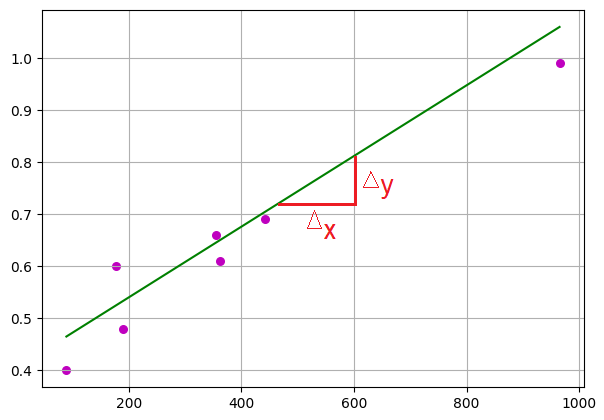

🙋 $\beta_1$

🤔💭 Então o problema está pedindo para testar a hipótese do $\beta_1$ com algum valor, certo? qual? 

🙋 A nova inclinação $\beta_{10}=\frac{Δy}{Δx}$ #Conceito da inclinação de uma reta

Neste caso a variação em $y$, ou ${Δy}$ da reta, é 0,6 e a variação em x ou ${Δx}$ da reta é $x_2 - x_1$ onde $x_1=100$ e $x_2=1000$ assim ${Δx} = 900$

$\beta_{10}=\frac{0,6}{900}=0,0006667$

🤔💭 então eu devo testar a hipótese nula com esse dato?

🙋 Sim!, Verificar se $H_0$ é verdadeira para esse valor ou se é menor

Testar se $H_0: \beta_1=0,0006667$ é verdadeira vs. $H_a: \beta_1 < 0,0006667$

Da tabela t-student $t_{crit}$ para 5 gl para o nível de confiança de 95 \% 




In [10]:
#usar a tabela tstudent
from scipy.stats import t
alpha = 0.05  # nível de significia = 5% 
df = len(x) - 2 # graus de liberdade (Número de amostras menos dois)                                     
#
v = t.ppf(1 - alpha/2, df) 
tcrit=v
print(f'tcrit=: {v}') 

tcrit=: 2.570581835636315


Sendo que $\beta_{10} \neq 0$ a estatística de teste  será

$t=\frac{\hat{\beta}_1-\beta_{10}}{s_{\hat{\beta}_1}}$ # da reta $\beta_1=0,00062108$

$t=\frac{0,00062108-0,0006667}{0,0000758}=-0,60185$

Agora é necessário comparar se:

$|t| \geq t_{crit}$

$ -0,61 \geq 2,5706$ ❎

Portanto não ha evidencia suficiente para rejeitar $H_0$ em favor de $H_a$,  $H_a: \beta_1 < 0,0006667$ não é verdadeira.
Dito de outra forma não há evidência suficiente de que com um aumento de 100 para 1000, o verdadeiro aumento médio em y é menor que 0,6.

Obs. Os resultados do quadro OLS tem od dados do teste de hipótese apenas para validar a funcionalidade do modelo.

## Resposta d.

Estime a mudança média verdadeira na névoa associada com um aumento de velocidade de 1 cm/s. Faça isso de maneira que transmita informações sobre precisão e confiança.

Usar as informações obtidas previamente

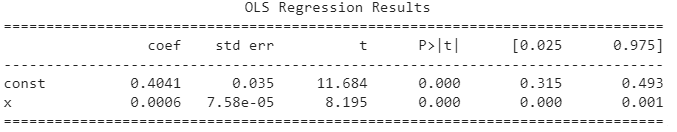

IC de $\beta_1= \hat{\beta}_1 \pm t_{\frac{\alpha}{2},n-2} s_{\hat{\beta}_1}  $

In [11]:
#Cálculo do intervalo de confiança de b1
#v é o nome com que foi armazenado t_crit
b1a=b1+v*7.58e-5
b1b=b1-v*7.58e-5
b1b,b1a

(np.float64(0.0004262257319255606), np.float64(0.0008159259382080259))

In [12]:
#Alguns complementos para observação 
y_pred=modelo.predict()
y_pred

array([0.45939953, 0.51405421, 0.52150712, 0.62398463, 0.62895324,
       0.6786393 , 1.00346197])

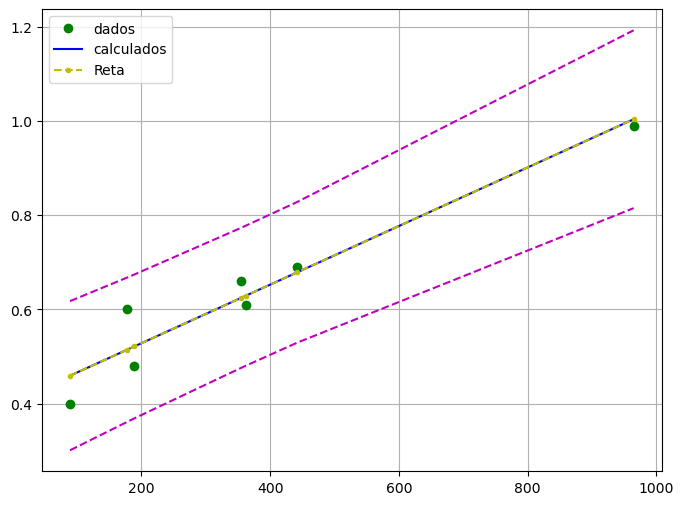

In [13]:
#Observar o intervalo de previsão
pred_ols = modelo.get_prediction()
iv_l = pred_ols.summary_frame()["obs_ci_lower"] #dentro [] define só mostrar extremos
iv_u = pred_ols.summary_frame()["obs_ci_upper"]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, y, "go", label="dados")
ax.plot(x, y_pred, "b-", label="calculados")
ax.plot(x, modelo.fittedvalues, "y--.", label="Reta")
ax.plot(x, iv_u, "m--")
ax.plot(x, iv_l, "m--")
ax.legend(loc="best")
plt.grid(True)